In [2]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X, y=make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=0)

In [3]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [4]:
def logistic_gd(X, y, lr=0.1, epochs=1000):
    n, d=X.shape   #n=number of samples=300, d=2 (no. of features)
    w=np.zeros(d) #one weight per feature now (2 features)
    b=0.0
    losses=[]

    for _ in range(epochs):
        z=X @ w + b    # X @ w is matrix-vector multiplication
        y_hat=sigmoid(z)

        eps=1e-9  # avoid log(0)
        loss=-np.mean(y* np.log(y_hat + eps)+(1-y)* np.log(1-y_hat + eps))
        losses.append(loss)

        err=y_hat - y
        dw=(X.T @ err)/n    #X.T transposes X
        db=err.mean()

        w-= lr*dw
        b-=lr*db
    return w, b, losses

In [6]:
w, b, losses=logistic_gd(X, y, lr=0.1, epochs=1000)
print(f"Learned: e={w}, b={b:.4f}")

from sklearn.linear_model import LogisticRegression
sk=LogisticRegression().fit(X, y)
print(f"sklearn: w={sk.coef_[0]}, b={sk.intercept_[0]:.4f}")

Learned: e=[-1.93994078  3.05994497], b=1.1430
sklearn: w=[-2.12579509  2.99705286], b=1.4843


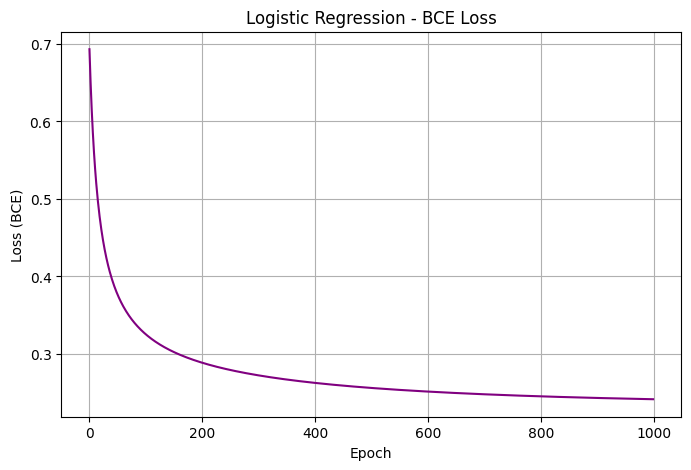

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(losses, color="purple")
plt.title("Logistic Regression - BCE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.grid(True)
plt.show()

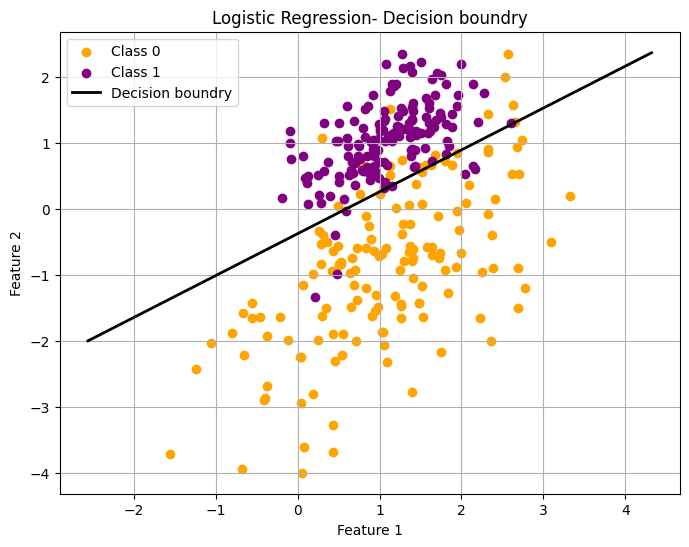

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0][:,0], X[y==0][:,1], color="orange", label="Class 0")
plt.scatter(X[y==1][:,0], X[y==1][:,1], color="purple", label="Class 1")

x1_vals=np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x2_vals=-(w[0]* x1_vals + b)/ w[1]  #decision boundry: w0*x1 + w1*x2 + b=0, solve for x2
plt.plot(x1_vals, x2_vals, color="black", linewidth=2, label="Decision boundry")

plt.title("Logistic Regression- Decision boundry")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Note — Why sklearn's weights differed from mine

**What happened:** my from-scratch weights `w=[-1.94, 3.06]` and sklearn's `w=[-2.13, 3.00]` were close but not identical.

**Why:** sklearn's `LogisticRegression` applies **L2 regularization** by default, mine doesn't.

- My loss: `BCE(predictions, actual)` — pure accuracy.
- sklearn's loss: `BCE(predictions, actual) + (1/C) * (w1² + w2² + ...)` — accuracy + a penalty for large weights (`C=1.0` by default).

**Why penalize large weights?** Large weights often mean the model is fitting noise/quirks specific to the training data (overfitting). Penalizing them trades a little training accuracy for better generalization to new data — same idea as the bias-variance tradeoff, just applied to the weights directly.

**Neither is wrong** — different objectives. To confirm regularization was the actual cause of the gap:
```python
sk_noreg = LogisticRegression(penalty=None).fit(X, y)
```
If this lands closer to my weights, that confirms it.